# CVPDL HW2 — Long-Tail Detection with YOLOv12m (Training From Scratch)

> **Important:** The notebook assumes the working directory is `H2/CVPDL_hw2/CVPDL_hw2`. Adjust paths in the configuration if you copy it elsewhere.

## 1. Environment Setup

Uncomment the `%pip` line if your environment is missing the Ultralytics package.

In [1]:
# Optional: install Ultralytics if it is not already available
# %pip install -q ultralytics

In [2]:
import os
import math
import shutil
import random
import yaml
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Sequence

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO
from tqdm.auto import tqdm

# Deterministic-ish behaviour
DEFAULT_SEED = 202754385

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(DEFAULT_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


/home/tony/anaconda3/envs/CV/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

All key paths and hyperparameters live in the `TrainConfig`. You can adjust the validation split, training epochs, and YOLO image size here.

In [3]:
@dataclass
class TrainConfig:
    project_root: Path = Path.cwd()
    raw_train_dir: Path = Path.cwd() / "train"
    raw_test_dir: Path = Path.cwd() / "test"

    yolo_root: Path = Path.cwd() / "yolo_dataset"
    dataset_yaml_name: str = "yolov12_dataset.yaml"
    yolo_images_train: Path = yolo_root / "images" / "train"
    yolo_images_val: Path = yolo_root / "images" / "val"
    yolo_images_test: Path = yolo_root / "images" / "test"
    yolo_labels_train: Path = yolo_root / "labels" / "train"
    yolo_labels_val: Path = yolo_root / "labels" / "val"

    dataset_yaml: Path = yolo_root / dataset_yaml_name
    model_dir: Path = Path.cwd() / "models"
    model_yaml: Path = model_dir / "yolov12m.yaml"

    runs_dir: Path = Path.cwd() / "runs"
    run_name: str = "yolov12m_2880_bs1_300ep"
    folds_root: Path = Path.cwd() / "yolo_folds"

    num_classes: int = 4
    class_names: Tuple[str, ...] = ("Car", "Hov", "Person", "Motorcycle")

    val_split: float = 0.1
    seed: int = 202754385
    use_kfold: bool = False
    k_folds: int = 5
    kfold_primary_fold: int = 0
    kfold_reuse_existing: bool = False
    kfold_copy_test: bool = False
    kfold_fuse_iou: float = 0.55
    kfold_output_name: Optional[str] = None

    image_size: int = 2880
    batch_size: int = 1
    num_workers: int = 12
    num_epochs: int = 300
    learning_rate: float = 5.0e-5
    weight_decay: float = 5.0e-4
    warmup_epochs: float = 3.0
    patience: int = 25

    score_threshold: float = 0.01
    iou_threshold: float = 0.65
    dummy_conf: float = 1e-3
    dummy_label: int = 0
    
    # 長尾處理策略
    use_oversampling: bool = True
    use_undersampling: bool = False
    oversample_threshold: float = 0.3  # 物件數 < max_count * 0.3 視為稀有類別
    target_balance_ratio: float = 0.5  # 希望稀有類別佔比達到 50%
    undersample_head_ratio: float = 0.9   # 頻繁類別保留 60%
    
    # 類別感知增強參數
    head_class_aug_factor: float = 0.5   # head class 的增強強度降低到 50%
    tail_class_aug_factor: float = 2   # tail class 的增強強度提升到 150%
    class_aug_threshold: float = 0.3     # 區分 head/tail 的閾值（與 oversample_threshold 一致）
    
    

    def ensure_dirs(self) -> None:
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.runs_dir.mkdir(parents=True, exist_ok=True)
        self.yolo_root.mkdir(parents=True, exist_ok=True)
        self.folds_root.mkdir(parents=True, exist_ok=True)

    def reset_yolo_folders(self, dataset_root: Optional[Path] = None) -> None:
        root = Path(dataset_root) if dataset_root else self.yolo_root
        if root.exists():
            shutil.rmtree(root)
        (root / "images" / "train").mkdir(parents=True, exist_ok=True)
        (root / "images" / "val").mkdir(parents=True, exist_ok=True)
        (root / "images" / "test").mkdir(parents=True, exist_ok=True)
        (root / "labels" / "train").mkdir(parents=True, exist_ok=True)
        (root / "labels" / "val").mkdir(parents=True, exist_ok=True)
        (root / "labels" / "test").mkdir(parents=True, exist_ok=True)

    def dataset_yaml_for_root(self, root: Path) -> Path:
        return Path(root) / self.dataset_yaml_name

    def fold_root(self, fold_idx: int) -> Path:
        return self.folds_root / f"fold_{fold_idx + 1}"

    def fold_run_name(self, fold_idx: int) -> str:
        return f"{self.run_name}_fold{fold_idx + 1}"


cfg = TrainConfig()
cfg.ensure_dirs()
set_seed(cfg.seed)

print("Configuration:")
for k, v in asdict(cfg).items():
    print(f"  {k}: {v}")

assert cfg.raw_train_dir.exists(), f"Train directory not found: {cfg.raw_train_dir}"
assert cfg.raw_test_dir.exists(), f"Test directory not found: {cfg.raw_test_dir}"


Configuration:
  project_root: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2
  raw_train_dir: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/train
  raw_test_dir: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/test
  yolo_root: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset
  dataset_yaml_name: yolov12_dataset.yaml
  yolo_images_train: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset/images/train
  yolo_images_val: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset/images/val
  yolo_images_test: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset/images/test
  yolo_labels_train: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset/labels/train
  yolo_labels_val: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset/labels/val
  dataset_yaml: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset/yolov12_dataset.yaml
  model_dir: /home/tony/Downloads/NTU_CVPD

In [4]:
def hybrid_resample_dataset(
    train_records: List[Dict[str, Any]],
    cfg: TrainConfig,
) -> Tuple[List[Dict[str, Any]], Dict[int, str]]:
    """
    混合重採樣策略：
    1. Undersample head classes（減少 head-only 圖片）
    2. Oversample tail classes（複製含 tail 的圖片）
    
    Returns:
        resampled_records: 重採樣後的訓練記錄
        class_types: 每個類別的類型（'head' 或 'tail'）
    """
    # ============ 1. 計算初始類別分佈 ============
    class_counts = {}
    for cls_idx in range(cfg.num_classes):
        count = sum(
            int((record["labels"] == cls_idx).sum())
            for record in train_records
        )
        class_counts[cls_idx] = count
    
    if not class_counts:
        return train_records, {}
    
    max_count = max(class_counts.values())
    
    # 區分 head/tail 類別
    class_types = {}
    for cls_idx, count in class_counts.items():
        if count < max_count * cfg.oversample_threshold:
            class_types[cls_idx] = 'tail'
        else:
            class_types[cls_idx] = 'head'
    
    head_classes = [cls for cls, t in class_types.items() if t == 'head']
    tail_classes = [cls for cls, t in class_types.items() if t == 'tail']
    
    print("\n" + "="*60)
    print("📊 Initial Class Distribution")
    print("="*60)
    for cls_idx, cls_name in enumerate(cfg.class_names):
        count = class_counts[cls_idx]
        cls_type = class_types[cls_idx]
        pct = count / max_count * 100
        print(f"  {cls_name:12} ({cls_type:4}): {count:6,} objects ({pct:5.1f}%)")
    
    # ============ 2. Undersample Head Classes ============
    resampled = []
    
    if cfg.use_undersampling and head_classes:
        print(f"\n🔽 Undersampling head classes (keep {cfg.undersample_head_ratio:.0%}):")
        
        # 分類圖片：head-only vs mixed (含 tail)
        head_only_images = []
        mixed_images = []
        
        for rec in train_records:
            labels_set = set(rec["labels"].tolist())
            has_tail = any(cls in tail_classes for cls in labels_set)
            has_head = any(cls in head_classes for cls in labels_set)
            
            if has_tail:
                mixed_images.append(rec)  # 含 tail 的圖片全保留
            elif has_head:
                head_only_images.append(rec)  # 僅含 head 的圖片
        
        # 隨機 undersample head-only 圖片
        rng = np.random.default_rng(cfg.seed)
        keep_count = int(len(head_only_images) * cfg.undersample_head_ratio)
        if keep_count < len(head_only_images):
            rng.shuffle(head_only_images)
            head_only_images = head_only_images[:keep_count]
            print(f"  → Reduced head-only images: {len(train_records) - len(mixed_images)} → {len(head_only_images)}")
        
        resampled = mixed_images + head_only_images
        print(f"  → Dataset after undersampling: {len(train_records)} → {len(resampled)} images")
    else:
        resampled = list(train_records)
    
    # ============ 3. Oversample Tail Classes ============
    if cfg.use_oversampling and tail_classes:
        print(f"\n🔼 Oversampling tail classes (target: {cfg.target_balance_ratio:.0%} of max):")
        
        # 重新計算 undersample 後的類別數量
        class_counts_after = {}
        for cls_idx in range(cfg.num_classes):
            count = sum(
                int((record["labels"] == cls_idx).sum())
                for record in resampled
            )
            class_counts_after[cls_idx] = count
        
        max_count_after = max(class_counts_after.values())
        target_count = int(max_count_after * cfg.target_balance_ratio)
        
        for cls_idx in tail_classes:
            current_count = class_counts_after[cls_idx]
            if current_count >= target_count:
                continue
            
            # 找出包含此 tail class 的圖片（依 tail_ratio 排序）
            images_with_class = []
            for rec in resampled:
                if cls_idx not in rec["labels"]:
                    continue
                # 計算此圖片中 tail class 的比例
                total_objs = len(rec["labels"])
                tail_objs = int((rec["labels"] == cls_idx).sum())
                tail_ratio = tail_objs / max(total_objs, 1)
                images_with_class.append((rec, tail_ratio))
            
            if not images_with_class:
                continue
            
            # 優先複製 tail_ratio 高的圖片
            images_with_class.sort(key=lambda x: x[1], reverse=True)
            
            # 計算需要增加的 instance 數
            need_instances = target_count - current_count
            added_instances = 0
            duplicates = []
            
            idx = 0
            while added_instances < need_instances and idx < len(images_with_class):
                rec, _ = images_with_class[idx]
                duplicates.append(rec)
                added_instances += int((rec["labels"] == cls_idx).sum())
                idx += 1
                
                # 如果候選圖片不夠，就循環使用（最多複製 3 輪）
                if idx >= len(images_with_class) and added_instances < need_instances:
                    if len(duplicates) < len(images_with_class) * 3:
                        idx = 0  # 重新開始
                    else:
                        break  # 避免無限循環
            
            resampled.extend(duplicates)
            
            repeat_factor = (current_count + added_instances) / max(current_count, 1)
            print(f"  {cfg.class_names[cls_idx]:12}: {current_count:6,} → "
                  f"{current_count + added_instances:6,} (+{len(duplicates)} images, ×{repeat_factor:.2f})")
    
    # ============ 4. 最終統計 ============
    final_class_counts = {}
    for cls_idx in range(cfg.num_classes):
        count = sum(
            int((record["labels"] == cls_idx).sum())
            for record in resampled
        )
        final_class_counts[cls_idx] = count
    
    print("\n" + "="*60)
    print("📊 Final Class Distribution (After Hybrid Resampling)")
    print("="*60)
    max_final = max(final_class_counts.values())
    for cls_idx, cls_name in enumerate(cfg.class_names):
        count = final_class_counts[cls_idx]
        pct = count / max_final * 100
        cls_type = class_types[cls_idx]
        change = count - class_counts[cls_idx]
        change_str = f"({change:+,})" if change != 0 else ""
        print(f"  {cls_name:12} ({cls_type:4}): {count:6,} objects ({pct:5.1f}%) {change_str}")
    
    print(f"\n✅ Dataset size: {len(train_records)} → {len(resampled)} images")
    print("="*60 + "\n")
    
    return resampled, class_types

## 3. Data Conversion to YOLO Format

We convert the original annotations (stored as CSV-style lines per object) to YOLO text files with normalized `(class, x_center, y_center, width, height)` entries. Images are symlinked into `yolo_dataset/images/{train,val,test}` to avoid duplication (falls back to copying if symlinks are unavailable).

In [5]:
def write_dataset_yaml(
    cfg: TrainConfig,
    dataset_root: Optional[Path] = None,
    yaml_path: Optional[Path] = None,
) -> Path:
    root = Path(dataset_root) if dataset_root else cfg.yolo_root
    target_yaml = Path(yaml_path) if yaml_path else cfg.dataset_yaml_for_root(root)
    data = {
        "path": str(root),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {idx: name for idx, name in enumerate(cfg.class_names)},
    }
    target_yaml.parent.mkdir(parents=True, exist_ok=True)
    with target_yaml.open("w") as f:
        yaml.safe_dump(data, f, sort_keys=False)
    print(f"Dataset YAML written to {target_yaml}")
    return target_yaml

def write_dataset_yaml_with_class_info(
    cfg: TrainConfig,
    class_types: Dict[int, str],
    dataset_root: Optional[Path] = None,
    yaml_path: Optional[Path] = None,
) -> Path:
    """
    生成包含類別增強資訊的 dataset YAML。
    """
    root = Path(dataset_root) if dataset_root else cfg.yolo_root
    target_yaml = Path(yaml_path) if yaml_path else cfg.dataset_yaml_for_root(root)
    
    # 計算每個類別的增強因子
    class_aug_factors = {}
    for cls_idx, cls_type in class_types.items():
        if cls_type == 'tail':
            class_aug_factors[cls_idx] = cfg.tail_class_aug_factor
        else:
            class_aug_factors[cls_idx] = cfg.head_class_aug_factor
    
    data = {
        "path": str(root),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {idx: name for idx, name in enumerate(cfg.class_names)},
        # 自訂欄位（供您的自訂 DataLoader 使用）
        "class_types": {idx: cls_type for idx, cls_type in class_types.items()},
        "class_aug_factors": {idx: float(factor) for idx, factor in class_aug_factors.items()},
    }
    
    target_yaml.parent.mkdir(parents=True, exist_ok=True)
    with target_yaml.open("w") as f:
        yaml.safe_dump(data, f, sort_keys=False)
    
    print(f"📄 Dataset YAML (with class-aware aug info) → {target_yaml}")
    return target_yaml

In [6]:
def parse_annotation_file(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    if not path.exists():
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)

    boxes: List[List[float]] = []
    labels: List[int] = []

    with path.open("r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue
            parts = line.split(",")
            if len(parts) != 5:
                raise ValueError(f"Unexpected annotation in {path}: {raw_line}")
            cls, x, y, w, h = parts
            cls_id = int(cls)
            w = max(float(w), 1.0)
            h = max(float(h), 1.0)
            boxes.append([float(x), float(y), w, h])
            labels.append(cls_id)

    if not boxes:
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)

    return np.asarray(boxes, dtype=np.float32), np.asarray(labels, dtype=np.int64)


def xywh_to_yolo(boxes: np.ndarray, labels: np.ndarray, width: int, height: int) -> List[Tuple[int, float, float, float, float]]:
    if boxes.size == 0:
        return []
    x = boxes[:, 0]
    y = boxes[:, 1]
    w = boxes[:, 2]
    h = boxes[:, 3]

    x_center = (x + w / 2.0) / width
    y_center = (y + h / 2.0) / height
    w_norm = w / width
    h_norm = h / height

    valid = (w_norm > 0) & (h_norm > 0)
    records = []
    for cls, cx, cy, ww, hh, is_valid in zip(labels, x_center, y_center, w_norm, h_norm, valid):
        if not is_valid:
            continue
        cx = float(np.clip(cx, 0.0, 1.0))
        cy = float(np.clip(cy, 0.0, 1.0))
        ww = float(np.clip(ww, 1e-3, 1.0))
        hh = float(np.clip(hh, 1e-3, 1.0))
        records.append((int(cls), cx, cy, ww, hh))
    return records


def link_or_copy(src: Path, dst: Path) -> None:
    if dst.exists():
        return
    try:
        os.symlink(src.resolve(), dst)
    except OSError:
        shutil.copy2(src, dst)


def load_dataset_metadata(cfg: TrainConfig) -> List[Dict[str, Any]]:
    metadata: List[Dict[str, Any]] = []
    for image_path in sorted(cfg.raw_train_dir.glob("img*.png")):
        ann_path = image_path.with_suffix(".txt")
        boxes, labels = parse_annotation_file(ann_path)
        with Image.open(image_path) as img:
            width, height = img.size
        metadata.append({
            "image_path": image_path,
            "ann_path": ann_path,
            "image_id": int(image_path.stem.replace("img", "")),
            "width": width,
            "height": height,
            "boxes": boxes,
            "labels": labels,
        })
    return metadata


def prepare_yolo_dataset(
    cfg: TrainConfig,
    metadata: Optional[List[Dict[str, Any]]] = None,
    train_indices: Optional[Sequence[int]] = None,
    val_indices: Optional[Sequence[int]] = None,
    dataset_root: Optional[Path] = None,
    copy_test: bool = True,
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    dataset_root = Path(dataset_root) if dataset_root else cfg.yolo_root
    metadata = metadata if metadata is not None else load_dataset_metadata(cfg)

    cfg.reset_yolo_folders(dataset_root)

    total_records = len(metadata)
    if total_records == 0:
        raise ValueError("No training annotations were found.")

    if train_indices is None or val_indices is None:
        rng = np.random.default_rng(cfg.seed)
        indices = np.arange(total_records)
        rng.shuffle(indices)
        val_size = max(1, int(total_records * cfg.val_split))
        val_indices = indices[:val_size]
        train_indices = indices[val_size:]
    else:
        train_indices = np.asarray(train_indices, dtype=int)
        val_indices = np.asarray(val_indices, dtype=int)

    train_set = {int(idx) for idx in train_indices.tolist()}
    val_set = {int(idx) for idx in val_indices.tolist()}

    if not train_set:
        raise ValueError("Training split is empty.")
    if not val_set:
        raise ValueError("Validation split is empty.")

    images_train = dataset_root / "images" / "train"
    images_val = dataset_root / "images" / "val"
    images_test = dataset_root / "images" / "test"
    labels_train = dataset_root / "labels" / "train"
    labels_val = dataset_root / "labels" / "val"

    train_records: List[Dict[str, Any]] = []
    val_records: List[Dict[str, Any]] = []

    for idx, record in enumerate(metadata):
        subset = None
        if idx in train_set:
            subset = "train"
        elif idx in val_set:
            subset = "val"

        if subset is None:
            continue

        image_dest = (images_train if subset == "train" else images_val) / record["image_path"].name
        label_dest = (labels_train if subset == "train" else labels_val) / (record["image_path"].stem + ".txt")
        link_or_copy(record["image_path"], image_dest)

        yolo_records = xywh_to_yolo(record["boxes"], record["labels"], record["width"], record["height"])
        with label_dest.open("w") as f:
            for cls, cx, cy, ww, hh in yolo_records:
                f.write(f"{cls} {cx:.6f} {cy:.6f} {ww:.6f} {hh:.6f}\n")

        if subset == "train":
            train_records.append(record)
        else:
            val_records.append(record)

    if copy_test:
        for image_path in sorted(cfg.raw_test_dir.glob("img*.png")):
            dest = images_test / image_path.name
            link_or_copy(image_path, dest)

    print(f"Prepared YOLO dataset ({dataset_root}): {len(train_records)} train / {len(val_records)} val images")
    return train_records, val_records

def prepare_yolo_dataset_from_oversampled(
    cfg: TrainConfig,
    train_records: List[Dict[str, Any]],
    val_records: List[Dict[str, Any]],
) -> None:
    """
    將過採樣後的訓練記錄轉換為 YOLO 格式的檔案。
    
    注意：重複的圖片會建立多個 symlink（檔名加上編號）。
    """
    cfg.reset_yolo_folders()
    
    images_train = cfg.yolo_images_train
    labels_train = cfg.yolo_labels_train
    images_val = cfg.yolo_images_val
    labels_val = cfg.yolo_labels_val
    
    # 記錄每張圖片被複製的次數（用於編號）
    image_counters: Dict[int, int] = {}
    
    # 處理訓練集（包含重複的記錄）
    for record in tqdm(train_records, desc="Preparing oversampled train set"):
        image_id = record["image_id"]
        
        # 產生唯一的檔名
        count = image_counters.get(image_id, 0)
        image_counters[image_id] = count + 1
        
        if count == 0:
            # 第一次出現：使用原始檔名
            image_dest = images_train / record["image_path"].name
            label_dest = labels_train / (record["image_path"].stem + ".txt")
        else:
            # 重複出現：檔名加上編號
            stem = record["image_path"].stem
            suffix = record["image_path"].suffix
            image_dest = images_train / f"{stem}_dup{count}{suffix}"
            label_dest = labels_train / f"{stem}_dup{count}.txt"
        
        # 建立連結或複製檔案
        link_or_copy(record["image_path"], image_dest)
        
        # 寫入標註
        yolo_records = xywh_to_yolo(
            record["boxes"],
            record["labels"],
            record["width"],
            record["height"],
        )
        with label_dest.open("w") as f:
            for cls, cx, cy, ww, hh in yolo_records:
                f.write(f"{cls} {cx:.6f} {cy:.6f} {ww:.6f} {hh:.6f}\n")
    
    # 處理驗證集（不重複）
    for record in tqdm(val_records, desc="Preparing val set"):
        image_dest = images_val / record["image_path"].name
        label_dest = labels_val / (record["image_path"].stem + ".txt")
        
        link_or_copy(record["image_path"], image_dest)
        
        yolo_records = xywh_to_yolo(
            record["boxes"],
            record["labels"],
            record["width"],
            record["height"],
        )
        with label_dest.open("w") as f:
            for cls, cx, cy, ww, hh in yolo_records:
                f.write(f"{cls} {cx:.6f} {cy:.6f} {ww:.6f} {hh:.6f}\n")
    
    # 複製測試集
    for image_path in sorted(cfg.raw_test_dir.glob("img*.png")):
        dest = cfg.yolo_images_test / image_path.name
        link_or_copy(image_path, dest)
    
    print(f"✅ Oversampled dataset prepared: {len(train_records)} train / {len(val_records)} val images")

dataset_metadata = load_dataset_metadata(cfg)
train_split, val_split = prepare_yolo_dataset(cfg, metadata=dataset_metadata)


# 🆕 執行混合重採樣（取代原本的 oversample_rare_classes）
if cfg.use_oversampling or cfg.use_undersampling:
    print("\n🔄 Starting Hybrid Resampling...")
    train_split, class_types = hybrid_resample_dataset(train_split, cfg)
    
    # 重新準備 YOLO 資料集
    prepare_yolo_dataset_from_oversampled(cfg, train_split, val_split)
    
    # 生成包含類別資訊的 dataset YAML
    dataset_yaml_path = write_dataset_yaml_with_class_info(cfg, class_types)
    print(f"✅ Using resampled dataset with class-aware augmentation info")
else:
    print("\n⏭️ Skipping resampling")
    dataset_yaml_path = write_dataset_yaml(cfg)
    print(f"✅ Using original dataset without resampling")

cfg.dataset_yaml = dataset_yaml_path
print(f"📄 Dataset YAML: {dataset_yaml_path}\n")

Prepared YOLO dataset (/home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset): 855 train / 95 val images

🔄 Starting Hybrid Resampling...

📊 Initial Class Distribution
  Car          (head): 21,313 objects (100.0%)
  Hov          (tail):  1,205 objects (  5.7%)
  Person       (tail):  2,891 objects ( 13.6%)
  Motorcycle   (tail):  4,737 objects ( 22.2%)

🔼 Oversampling tail classes (target: 50% of max):
  Hov         :  1,205 →  4,820 (+1488 images, ×4.00)
  Person      :  2,891 → 10,656 (+606 images, ×3.69)
  Motorcycle  :  4,737 → 10,693 (+230 images, ×2.26)

📊 Final Class Distribution (After Hybrid Resampling)
  Car          (head): 72,956 objects (100.0%) (+51,643)
  Hov          (tail):  6,245 objects (  8.6%) (+5,040)
  Person       (tail): 18,812 objects ( 25.8%) (+15,921)
  Motorcycle   (tail): 28,750 objects ( 39.4%) (+24,013)

✅ Dataset size: 855 → 3179 images



Preparing val set: 100%|██████████| 95/95 [00:00<00:00, 2351.15it/s]

✅ Oversampled dataset prepared: 3179 train / 95 val images
📄 Dataset YAML (with class-aware aug info) → /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset/yolov12_dataset.yaml
✅ Using resampled dataset with class-aware augmentation info
📄 Dataset YAML: /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset/yolov12_dataset.yaml



### 3.1 Dataset statistics

Quick overview of the annotation distribution after the split.

In [7]:
def build_stats(records: List[Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for item in records:
        labels = item["labels"]
        counts = np.bincount(labels, minlength=cfg.num_classes) if labels.size else np.zeros(cfg.num_classes, dtype=int)
        row = {
            "image_id": item["image_id"],
            "num_boxes": int(labels.size),
        }
        for cls_idx in range(cfg.num_classes):
            row[f"class_{cls_idx}"] = int(counts[cls_idx])
        rows.append(row)
    return pd.DataFrame(rows)

train_stats = build_stats(train_split)
val_stats = build_stats(val_split)

print("Train split summary:")
display(train_stats.describe(include="all"))
print("Validation split summary:")
display(val_stats.describe(include="all"))

Train split summary:


,image_id,num_boxes,class_0,class_1,class_2,class_3
count,3179.000000,3179.000000,3179.000000,3179.000000,3179.000000,3179.000000
mean,462.333753,39.875118,22.949355,1.964454,5.917584,9.043724
std,262.825799,30.670252,21.100309,2.012937,11.834558,12.909558
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,233.000000,14.000000,7.000000,1.000000,0.000000,0.000000
50%,466.000000,34.000000,14.000000,1.000000,1.000000,4.000000
75%,690.000000,61.000000,34.000000,2.000000,5.000000,11.000000
max,950.000000,168.000000,129.000000,15.000000,90.000000,59.000000


Validation split summary:


,image_id,num_boxes,class_0,class_1,class_2,class_3
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,457.768421,33.526316,20.652632,1.473684,4.968421,6.431579
std,274.494834,28.730161,19.197057,1.623249,12.667980,9.871141
min,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,226.000000,9.500000,6.000000,0.000000,0.000000,0.000000
50%,464.000000,24.000000,12.000000,1.000000,1.000000,2.000000
75%,685.500000,52.000000,34.000000,2.000000,3.000000,10.000000
max,936.000000,127.000000,80.000000,7.000000,97.000000,48.000000


### 3.1.1 類別分佈概覽

快速確認 train/val split 中各類別的物件數量與比例，協助評估樣本是否失衡。

,class,train_objects,val_objects,train_pct
0,Car,"72,956","1,962",57.55%
1,Motorcycle,"28,750",611,22.68%
2,Person,"18,812",472,14.84%
3,Hov,"6,245",140,4.93%


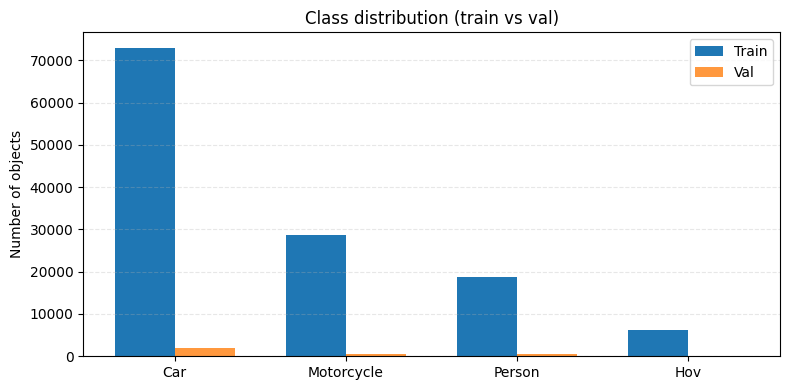

In [8]:
train_stats = build_stats(train_split)
val_stats = build_stats(val_split)

class_cols = [f"class_{cls_idx}" for cls_idx in range(cfg.num_classes)]
class_names = list(cfg.class_names)

train_counts = train_stats[class_cols].sum()
val_counts = val_stats[class_cols].sum()

class_counts_df = pd.DataFrame({
    "class": class_names,
    "train_objects": [int(train_counts.iloc[i]) for i in range(cfg.num_classes)],
    "val_objects": [int(val_counts.iloc[i]) for i in range(cfg.num_classes)],
})
class_counts_df["train_pct"] = class_counts_df["train_objects"] / max(class_counts_df["train_objects"].sum(), 1) * 100
class_counts_df = class_counts_df.sort_values("train_objects", ascending=False).reset_index(drop=True)

display(class_counts_df.style.format({
    "train_objects": "{:,}",
    "val_objects": "{:,}",
    "train_pct": "{:.2f}%",
}))

x = np.arange(len(class_counts_df))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, class_counts_df["train_objects"], width=width, label="Train", color="#1f77b4")
ax.bar(x + width / 2, class_counts_df["val_objects"], width=width, label="Val", color="#ff7f0e", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(class_counts_df["class"])
ax.set_ylabel("Number of objects")
ax.set_title("Class distribution (train vs val)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1.2 長尾特性診斷

透過更多面向（影像覆蓋率、累積份額、共現矩陣）評估長尾類別與資料稀疏區域，方便決定後續抽樣或重加權策略。

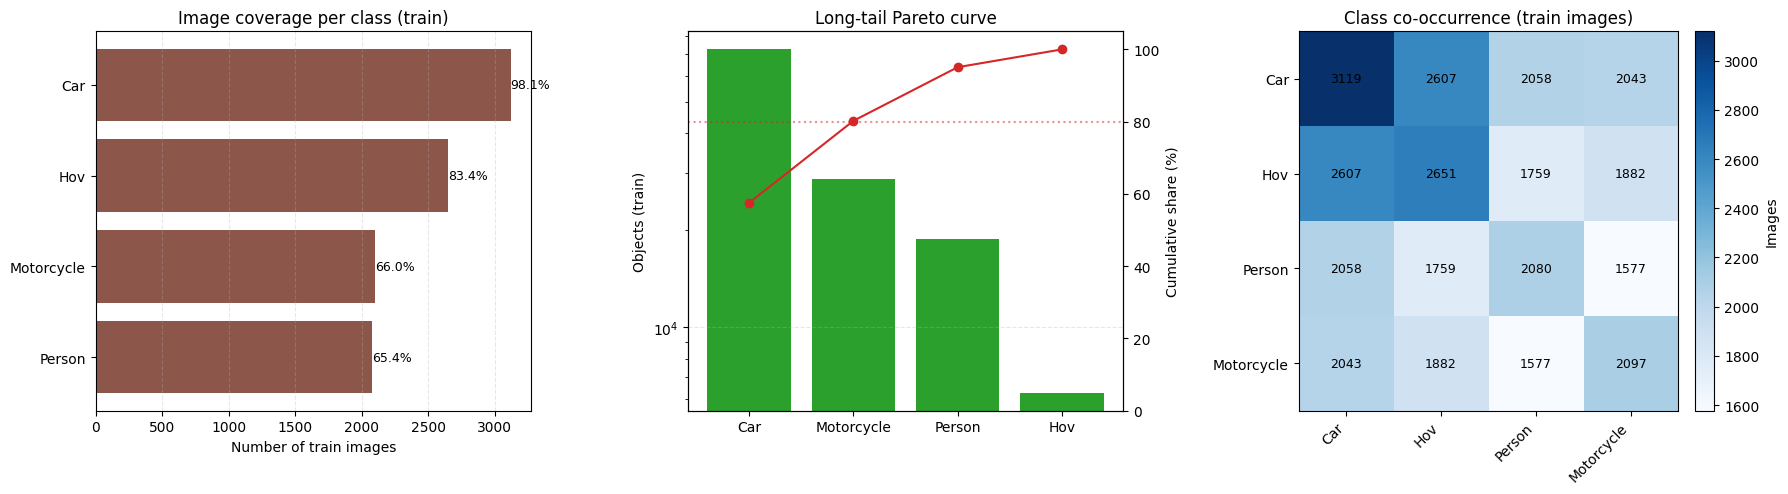

,image_id,num_boxes,Car,Hov,Person,Motorcycle
384,429,0,0,0,0,0
64,77,0,0,0,0,0
752,838,1,0,0,0,1
432,486,1,0,0,0,1
2950,486,1,0,0,0,1


In [9]:
class_cols = [f"class_{cls_idx}" for cls_idx in range(cfg.num_classes)]
class_names = list(cfg.class_names)

train_presence = (train_stats[class_cols] > 0).astype(int)
images_per_class = train_presence.sum()
images_per_class.index = class_names
image_share = images_per_class / max(len(train_stats), 1) * 100

class_counts = train_stats[class_cols].sum()
class_counts.index = class_names
long_tail_order = class_counts.sort_values(ascending=False)
cumulative_share = long_tail_order.cumsum() / max(long_tail_order.sum(), 1) * 100

per_image_objects = train_stats["num_boxes"]

co_matrix = np.zeros((cfg.num_classes, cfg.num_classes), dtype=int)
for row in train_presence.itertuples(index=False):
    present = np.array(row, dtype=bool)
    active = np.where(present)[0]
    for i in active:
        for j in active:
            co_matrix[i, j] += 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sorted_images = images_per_class.sort_values()
axes[0].barh(sorted_images.index, sorted_images.values, color="#8c564b")
for idx, cls_name in enumerate(sorted_images.index):
    axes[0].text(sorted_images.values[idx] + 0.5, idx, f"{image_share.loc[cls_name]:.1f}%", va="center", fontsize=9)
axes[0].set_xlabel("Number of train images")
axes[0].set_title("Image coverage per class (train)")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)

axes[1].bar(long_tail_order.index, long_tail_order.values, color="#2ca02c")
axes[1].set_ylabel("Objects (train)")
axes[1].set_title("Long-tail Pareto curve")
axes[1].set_yscale("log")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
ax1b = axes[1].twinx()
ax1b.plot(long_tail_order.index, cumulative_share.values, color="#d62728", marker="o")
ax1b.set_ylabel("Cumulative share (%)")
ax1b.set_ylim(0, 105)
ax1b.axhline(80, color="#d62728", linestyle=":", alpha=0.5)
ax1b.grid(False)

im = axes[2].imshow(co_matrix, cmap="Blues")
axes[2].set_xticks(np.arange(cfg.num_classes))
axes[2].set_xticklabels(class_names, rotation=45, ha="right")
axes[2].set_yticks(np.arange(cfg.num_classes))
axes[2].set_yticklabels(class_names)
axes[2].set_title("Class co-occurrence (train images)")
for i in range(cfg.num_classes):
    for j in range(cfg.num_classes):
        axes[2].text(j, i, co_matrix[i, j], ha="center", va="center", color="black", fontsize=9)
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Images")

plt.tight_layout()
plt.show()

rare_examples = train_stats.sort_values("num_boxes").head(5).copy()
rename_map = {f"class_{idx}": name for idx, name in enumerate(class_names)}
rare_examples = rare_examples.rename(columns=rename_map)
display(rare_examples[["image_id", "num_boxes"] + class_names])

### 3.2 K-fold cross-validation utilities

Helper functions for preparing stratified folds (by image) and running a full training cycle per fold.

In [10]:
def write_dataset_yaml(
    cfg: TrainConfig,
    dataset_root: Optional[Path] = None,
    yaml_path: Optional[Path] = None,
) -> Path:
    root = Path(dataset_root) if dataset_root else cfg.yolo_root
    target_yaml = Path(yaml_path) if yaml_path else cfg.dataset_yaml_for_root(root)
    data = {
        "path": str(root),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {idx: name for idx, name in enumerate(cfg.class_names)},
    }
    target_yaml.parent.mkdir(parents=True, exist_ok=True)
    with target_yaml.open("w") as f:
        yaml.safe_dump(data, f, sort_keys=False)
    print(f"Dataset YAML written to {target_yaml}")
    return target_yaml

def write_dataset_yaml_with_class_info(
    cfg: TrainConfig,
    class_types: Dict[int, str],
    dataset_root: Optional[Path] = None,
    yaml_path: Optional[Path] = None,
) -> Path:
    """
    生成包含類別增強資訊的 dataset YAML。
    """
    root = Path(dataset_root) if dataset_root else cfg.yolo_root
    target_yaml = Path(yaml_path) if yaml_path else cfg.dataset_yaml_for_root(root)
    
    # 計算每個類別的增強因子
    class_aug_factors = {}
    for cls_idx, cls_type in class_types.items():
        if cls_type == 'tail':
            class_aug_factors[cls_idx] = cfg.tail_class_aug_factor
        else:
            class_aug_factors[cls_idx] = cfg.head_class_aug_factor
    
    data = {
        "path": str(root),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {idx: name for idx, name in enumerate(cfg.class_names)},
        # 自訂欄位（供您的自訂 DataLoader 使用）
        "class_types": {idx: cls_type for idx, cls_type in class_types.items()},
        "class_aug_factors": {idx: float(factor) for idx, factor in class_aug_factors.items()},
    }
    
    target_yaml.parent.mkdir(parents=True, exist_ok=True)
    with target_yaml.open("w") as f:
        yaml.safe_dump(data, f, sort_keys=False)
    
    print(f"📄 Dataset YAML (with class-aware aug info) → {target_yaml}")
    return target_yaml

In [11]:
def build_kfold_splits(metadata: Sequence[Dict[str, Any]], k: int, seed: int) -> List[Tuple[np.ndarray, np.ndarray]]:
    metadata = list(metadata)
    total = len(metadata)
    if total < 2:
        raise ValueError("Need at least two training images for k-fold cross validation.")
    if k < 2:
        raise ValueError("k must be at least 2.")

    k = min(k, total)
    indices = np.arange(total)
    rng = np.random.default_rng(seed)
    rng.shuffle(indices)
    folds = np.array_split(indices, k)

    splits: List[Tuple[np.ndarray, np.ndarray]] = []
    for fold_idx in range(k):
        val_fold = folds[fold_idx]
        train_parts = [fold for j, fold in enumerate(folds) if j != fold_idx and fold.size > 0]
        val_idx = np.array(sorted(val_fold.tolist()), dtype=int)
        if not train_parts or val_idx.size == 0:
            continue
        train_idx = np.concatenate(train_parts).astype(int)
        train_idx = np.sort(train_idx)
        splits.append((train_idx, val_idx))

    if not splits:
        raise ValueError("Unable to create non-empty folds; adjust k or check dataset size.")
    return splits


def train_one_fold(
    cfg: TrainConfig,
    metadata: Sequence[Dict[str, Any]],
    fold_idx: int,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    *,
    copy_test: bool = False,
    reuse_existing: bool = True,
) -> Path:
    metadata = list(metadata)
    fold_root = cfg.fold_root(fold_idx)
    fold_run_name = cfg.fold_run_name(fold_idx)
    fold_run_dir = cfg.runs_dir / fold_run_name
    best_path = fold_run_dir / "weights" / "best.pt"
    last_path = fold_run_dir / "weights" / "last.pt"

    if reuse_existing and (best_path.exists() or last_path.exists()):
        chosen = best_path if best_path.exists() else last_path
        print(f"Reusing existing weights for fold {fold_idx + 1}: {chosen}")
        return chosen

    prepare_yolo_dataset(
        cfg,
        metadata=metadata,
        train_indices=train_idx,
        val_indices=val_idx,
        dataset_root=fold_root,
        copy_test=copy_test,
    )

    dataset_yaml = write_dataset_yaml_with_class_info(
        cfg,
        dataset_root=fold_root,
        yaml_path=cfg.dataset_yaml_for_root(fold_root),
    )

    model = YOLO(cfg.model_yaml)
    print(f"Starting training for fold {fold_idx + 1}: train={len(train_idx)}, val={len(val_idx)}")
    model.train(
        data=str(dataset_yaml),
        epochs=cfg.num_epochs,
        imgsz=cfg.image_size,
        batch=cfg.batch_size,
        lr0=cfg.learning_rate,
        optimizer="AdamW",
        weight_decay=cfg.weight_decay,
        momentum=0.9,
        device=0 if torch.cuda.is_available() else "cpu",
        project=str(cfg.runs_dir),
        name=fold_run_name,
        pretrained=False,
        workers=cfg.num_workers,
        seed=cfg.seed,
        patience=cfg.patience,
        warmup_epochs=cfg.warmup_epochs,
        verbose=True,
        amp=True,
        cos_lr=True,
        close_mosaic=20,
        degrees=5.0,
        translate=0.05,
        scale=0.7,
        shear=0.0,
        perspective=0.0,
        flipud=0.1,
        fliplr=0.5,
        mosaic=0.8,
        mixup=0.2,
        copy_paste=0.3,
        hsv_h=0.03,
        hsv_s=0.7,
        hsv_v=0.5,
        cls=0.7,
    )

    if best_path.exists():
        return best_path
    if last_path.exists():
        return last_path
    raise FileNotFoundError(f"No weights produced for fold {fold_idx + 1} under {fold_run_dir}")


def run_kfold_training(
    cfg: TrainConfig,
    metadata: Sequence[Dict[str, Any]],
    k: Optional[int] = None,
    *,
    copy_test: bool = False,
    reuse_existing: bool = True,
) -> Tuple[List[Path], List[Tuple[np.ndarray, np.ndarray]]]:
    metadata = list(metadata)
    k = int(k or cfg.k_folds)
    splits = build_kfold_splits(metadata, k, cfg.seed)

    weight_paths: List[Path] = []
    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        weight_path = train_one_fold(
            cfg,
            metadata,
            fold_idx,
            train_idx,
            val_idx,
            copy_test=copy_test,
            reuse_existing=reuse_existing,
        )
        print(f"Fold {fold_idx + 1} weights: {weight_path}")
        weight_paths.append(weight_path)
    return weight_paths, splits


## 4. YOLO Dataset & Model Configuration Files

We generate two YAML files:
- `yolov12_dataset.yaml`: tells Ultralytics where to find train/val/test data.
- `yolov12m.yaml`: defines a YOLOv12m architecture (custom variant inspired by modern YOLO backbones) with randomly initialised weights.

## 5. Initialize YOLOv12m

Instantiate the model from the custom YAML. This loads **random** weights (no pretraining).

In [13]:
# write_model_yaml(cfg, True)

model = YOLO(cfg.model_yaml)
model.info(verbose=True)
print(f"Trainable parameters: {sum(p.numel() for p in model.model.parameters() if p.requires_grad):,}")

NotImplementedError: 'YOLO' model does not support '_new' mode for 'None' task.

In [ ]:
model.model.model

Sequential(
  (0): Conv(
    (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (1): Conv(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (2): C3k2(
    (cv1): Conv(
      (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): C3k(
        (cv1): Conv(
      

In [ ]:
# 在這加入
# 在 "# 在這加入" 的 cell 中加入以下程式碼

import torch.nn as nn

# ============================================================
# 1. 定義 Coordinate Attention 模組
# ============================================================
class CoordAttention(nn.Module):
    """
    Coordinate Attention Module (CVPR 2021)
    保留空間位置資訊的注意力機制，特別適合小物件檢測
    """
    def __init__(self, channels: int, reduction: int = 32):
        super().__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))  # 沿 H 方向池化
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))  # 沿 W 方向池化
        
        hidden = max(8, channels // reduction)
        self.conv1 = nn.Conv2d(channels, hidden, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(hidden)
        self.act = nn.SiLU()  # 使用 SiLU (與 YOLO 一致)
        
        self.conv_h = nn.Conv2d(hidden, channels, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(hidden, channels, kernel_size=1, stride=1, padding=0)
        
    def forward(self, x):
        identity = x
        b, c, h, w = x.shape
        
        # 分別沿 H 和 W 方向編碼位置資訊
        x_h = self.pool_h(x)  # [B, C, H, 1]
        x_w = self.pool_w(x).permute(0, 1, 3, 2)  # [B, C, W, 1]
        
        # 拼接並壓縮通道
        y = torch.cat([x_h, x_w], dim=2)  # [B, C, H+W, 1]
        y = self.act(self.bn1(self.conv1(y)))
        
        # 分割回 H 和 W 維度
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)  # [B, C, 1, W]
        
        # 生成注意力權重
        a_h = self.conv_h(x_h).sigmoid()  # [B, C, H, 1]
        a_w = self.conv_w(x_w).sigmoid()  # [B, C, 1, W]
        
        # 應用注意力權重
        out = identity * a_h * a_w
        return out


# ============================================================
# 2. 動態插入 Coordinate Attention 的輔助函數
# ============================================================
def try_get_out_channels(module: nn.Module) -> int:
    """嘗試從模組中推斷輸出通道數"""
    # 常見 YOLO 模組的通道數獲取方式
    if hasattr(module, 'cv3'):  # C2f/C3k2 類模組
        return module.cv3.conv.out_channels
    elif hasattr(module, 'cv2'):  # Conv 包裝類
        if hasattr(module.cv2, 'conv'):
            return module.cv2.conv.out_channels
        return module.cv2.out_channels
    elif hasattr(module, 'conv'):  # 標準 Conv
        return module.conv.out_channels
    elif hasattr(module, 'out_channels'):  # 直接屬性
        return module.out_channels
    elif hasattr(module, 'c'):  # 某些自訂模組
        return module.c
    return 0


def insert_coord_attention(
    model,
    target_layer_indices: list = [5, 8, 18, 22],  # 對應 YAML 中的 CBAM 位置
    reduction: int = 16,
) -> int:
    """
    在指定層後插入 Coordinate Attention
    
    Args:
        model: YOLO 模型
        target_layer_indices: 要插入 CA 的層索引 (建議與原 CBAM 位置一致)
        reduction: CA 的通道壓縮比例
        
    Returns:
        成功插入的 CA 模組數量
    """
    seq = list(model.model.model.children())
    new_seq = []
    inserted_count = 0
    
    for idx, m in enumerate(seq):
        new_seq.append(m)
        
        if idx in target_layer_indices:
            # 推斷通道數
            out_ch = try_get_out_channels(m)
            if out_ch > 0:
                ca = CoordAttention(out_ch, reduction=reduction)
                new_seq.append(ca)
                inserted_count += 1
                print(f"  ✓ Layer {idx:2d} ({type(m).__name__:15s}, ch={out_ch:4d}) → CA inserted")
            else:
                print(f"  ✗ Layer {idx:2d} ({type(m).__name__:15s}) → Failed (unknown channels)")
    
    # 替換模型的 Sequential
    model.model.model = nn.Sequential(*new_seq)
    return inserted_count


# ============================================================
# 3. 執行插入（自動檢測 CBAM 位置）
# ============================================================
print("=" * 70)
print("🔍 Analyzing model structure...")
print("=" * 70)

# 分析原始模型結構，找出 CBAM 層的位置
cbam_indices = []
for idx, module in enumerate(model.model.model):
    module_name = type(module).__name__
    if 'CBAM' in module_name:
        cbam_indices.append(idx)
        print(f"  Layer {idx:2d}: {module_name} (CBAM detected)")

if cbam_indices:
    print(f"\n✓ Found {len(cbam_indices)} CBAM layers at indices: {cbam_indices}")
    print("\n📌 Strategy: Replace CBAM with Coordinate Attention (CA)")
    
    # 移除原有的 CBAM 層
    new_model_list = []
    for idx, module in enumerate(model.model.model):
        if idx not in cbam_indices:
            new_model_list.append(module)
    model.model.model = nn.Sequential(*new_model_list)
    
    # 調整索引（因為移除了 CBAM）
    adjusted_indices = []
    removed_count = 0
    for idx in cbam_indices:
        adjusted_indices.append(idx - removed_count - 1)  # 在前一層後插入
        removed_count += 1
    
    print(f"  → Adjusted insertion indices: {adjusted_indices}")
    
else:
    print("\n⚠️  No CBAM layers found, using default positions:")
    # 預設插入位置（對應 Backbone P3/P4 和 Head P3/P4）
    adjusted_indices = [4, 7, 17, 21]  # 根據您的 YAML 調整
    print(f"  → Default indices: {adjusted_indices}")

print("\n" + "=" * 70)
print("🚀 Inserting Coordinate Attention modules...")
print("=" * 70)

n_inserted = insert_coord_attention(
    model,
    target_layer_indices=adjusted_indices,
    reduction=16,  # 通道壓縮比例（16 是常用值）
)

print("=" * 70)
print(f"✅ Successfully inserted {n_inserted} Coordinate Attention modules")
print("=" * 70)

# ============================================================
# 4. 驗證修改後的模型
# ============================================================
print("\n📊 Updated Model Summary:")
model.info(verbose=False)
print(f"\n✓ Trainable parameters: {sum(p.numel() for p in model.model.parameters() if p.requires_grad):,}")

# 測試前向傳播（確保模型可用）
try:
    dummy_input = torch.randn(1, 3, 640, 640).to(device)
    with torch.no_grad():
        _ = model.model(dummy_input)
    print("✓ Forward pass test: PASSED ✓")
except Exception as e:
    print(f"✗ Forward pass test: FAILED")
    print(f"Error: {e}")


🔍 Analyzing model structure...
  Layer  5: CBAM (CBAM detected)
  Layer  8: CBAM (CBAM detected)
  Layer 18: CBAM (CBAM detected)
  Layer 22: CBAM (CBAM detected)

✓ Found 4 CBAM layers at indices: [5, 8, 18, 22]

📌 Strategy: Replace CBAM with Coordinate Attention (CA)
  → Adjusted insertion indices: [4, 6, 15, 18]

🚀 Inserting Coordinate Attention modules...
  ✓ Layer  4 (C3k2           , ch= 512) → CA inserted
  ✓ Layer  6 (A2C2f          , ch= 512) → CA inserted
  ✓ Layer 15 (A2C2f          , ch= 256) → CA inserted
  ✓ Layer 18 (A2C2f          , ch= 512) → CA inserted
✅ Successfully inserted 4 Coordinate Attention modules

📊 Updated Model Summary:

✓ Trainable parameters: 20,961,116
✗ Forward pass test: FAILED
Error: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same


## 6. Training

Train using Ultralytics' trainer with the custom dataset. Adjust epochs, batch size, or learning rate if you need to squeeze into your GPU budget. Mixed precision is automatically enabled on CUDA devices.

In [ ]:
train_results = None
# model = YOLO('/home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/runs/yolov12m_2880/weights/best.pt')
kfold_weight_paths: List[Path] = []
kfold_splits: List[Tuple[np.ndarray, np.ndarray]] = []

if cfg.use_kfold:
    kfold_weight_paths, kfold_splits = run_kfold_training(
        cfg,
        dataset_metadata,
        k=cfg.k_folds,
        copy_test=cfg.kfold_copy_test,
        reuse_existing=cfg.kfold_reuse_existing,
    )
    print(f"K-fold training finished with {len(kfold_weight_paths)} folds.")
else:
    train_results = model.train(
        data=str(cfg.dataset_yaml),
        epochs=cfg.num_epochs,
        imgsz=cfg.image_size,
        batch=cfg.batch_size,
        lr0=cfg.learning_rate,
        optimizer="AdamW",
        weight_decay=cfg.weight_decay,
        cls=0.5,
        momentum=0.9,
        device=0 if torch.cuda.is_available() else "cpu",
        project=str(cfg.runs_dir),
        name=cfg.run_name,
        pretrained=False,
        workers=cfg.num_workers,
        seed=cfg.seed,
        patience=cfg.patience,
        warmup_epochs=cfg.warmup_epochs,
        verbose=True,
        amp=True,                 # AMP 開
        cos_lr=True,              # 餘弦學習率
        close_mosaic=10,          # 最後 15 個 epoch 關閉 mosaic（收斂更穩）

        # 幾何增強（保守，避免把小物件變得更小或變形）
        # degrees=5.0,              # 小角度旋轉即可（航拍不需大旋轉）
        translate=0.1,           # 平移小一點，避免標註出框
        scale=0.7,                # Ultralytics 的 scale=0.2 ≈ 0.8~1.2，避免把物件縮太小
        shear=0.0,                # 盡量不用 shear（對小物件不友善）
        perspective=0.0,          # 航拍本來就近似正射，不需要

        # 翻轉
        flipud=0.0,               # 航拍上下翻轉偶爾可接受（若道路朝向敏感可改 0.0）
        fliplr=0.5,               # 左右翻轉保留

        # 影像混合類
        mosaic=0.2,              # 低比例 Mosaic（有助樣本多樣性，但小物件勿過高）
        mixup=0.0,               # 少量 MixUp（長尾類的正則化）；若雜訊多可改 0.0
        copy_paste=0.5,           # YOLO 官方 copy_paste 對 seg 最有效；檢測可留 0.0

        # 顏色/亮度（保守，避免把灰色道路/綠地偏色過頭）
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
    )


Ultralytics 8.3.221 🚀 Python-3.11.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/yolo_dataset/yolov12_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/models/yolov12m.yaml, momentum=0.9, mosaic=0.4, multi_scale=False, name=yol

In [19]:
if cfg.use_kfold:
    if not kfold_weight_paths:
        raise RuntimeError("未找到 k-fold 權重，請先執行 run_kfold_training 或將 cfg.use_kfold 設為 False。")
    fold_idx = max(0, min(cfg.kfold_primary_fold, len(kfold_weight_paths) - 1))
    best_weights_path = Path(kfold_weight_paths[fold_idx]).resolve()
    print(f"使用第 {fold_idx + 1} 折權重：{best_weights_path}")
else:
    weights_dir = cfg.runs_dir / cfg.run_name / "weights"
    best_candidate = weights_dir / "best.pt"
    if best_candidate.exists():
        best_weights_path = best_candidate.resolve()
    else:
        last_candidate = weights_dir / "last.pt"
        if last_candidate.exists():
            best_weights_path = last_candidate.resolve()
        else:
            raise FileNotFoundError(f"找不到模型權重，請先完成訓練：{weights_dir}")
    print(f"使用單一模型權重：{best_weights_path}")


TypeError: unsupported operand type(s) for /: 'str' and 'str'

### 6.1 Training curves

Ultralytics stores logs in `results.csv`. We can quickly visualise the learning curves.

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,273.300,3.40310,3.08135,1.81081,0.31417,0.24872,0.21130,0.06687,2.55229,1.75262,1.46149,0.066855,0.000167,0.000167
1,2,539.052,2.69578,2.05829,1.44497,0.35123,0.29741,0.27893,0.09370,2.33262,1.51714,1.33241,0.033688,0.000333,0.000333
2,3,804.634,2.52410,1.77542,1.36255,0.44059,0.35315,0.34753,0.12080,2.22573,1.37136,1.29927,0.000521,0.000500,0.000500
3,4,1070.230,2.43494,1.63938,1.32520,0.51956,0.40418,0.41331,0.14626,2.15297,1.26523,1.26593,0.000500,0.000500,0.000500
4,5,1333.410,2.37300,1.50382,1.29389,0.57260,0.45061,0.45931,0.16103,2.15520,1.21869,1.25752,0.000500,0.000500,0.000500


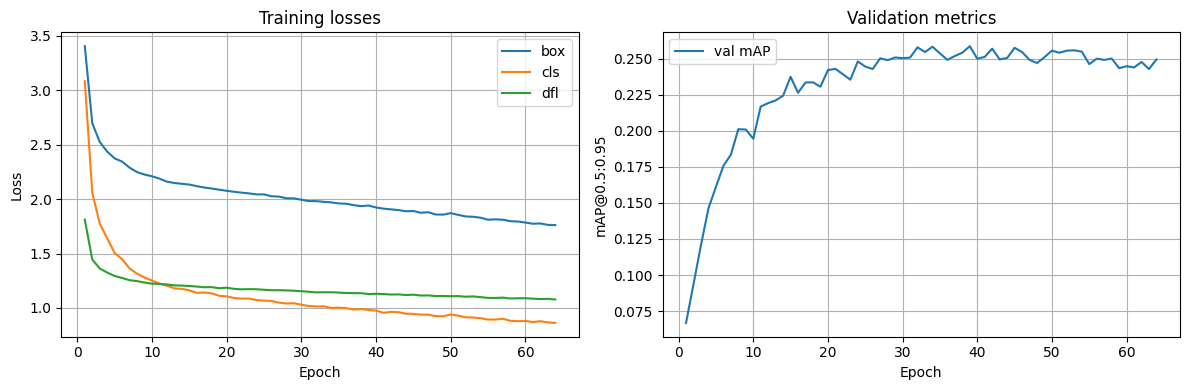

In [21]:
results_csv = best_weights_path.parent.parent / "results.csv"
if results_csv.exists():
    history = pd.read_csv(results_csv)
    display(history.head())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["epoch"], history["train/box_loss"], label="box")
    axes[0].plot(history["epoch"], history["train/cls_loss"], label="cls")
    axes[0].plot(history["epoch"], history["train/dfl_loss"], label="dfl")
    axes[0].set_title("Training losses")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    if "metrics/mAP50-95(B)" in history.columns:
        axes[1].plot(history["epoch"], history["metrics/mAP50-95(B)"], label="val mAP")
        axes[1].set_ylabel("mAP@0.5:0.95")
    else:
        axes[1].plot(history["epoch"], history["val/box_loss"], label="val box")
        axes[1].plot(history["epoch"], history["val/cls_loss"], label="val cls")
        axes[1].plot(history["epoch"], history["val/dfl_loss"], label="val dfl")
        axes[1].set_ylabel("Loss")
    axes[1].set_title("Validation metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
else:
    print("results.csv not found. Train the model first.")

### 6.2 Continue Training (Optional)

If you want to continue training from the best checkpoint for additional epochs, run the cell below.

## 7. Validation Preview

Load the best checkpoint and visualise predictions on a few validation images to ensure the detector behaves as expected.

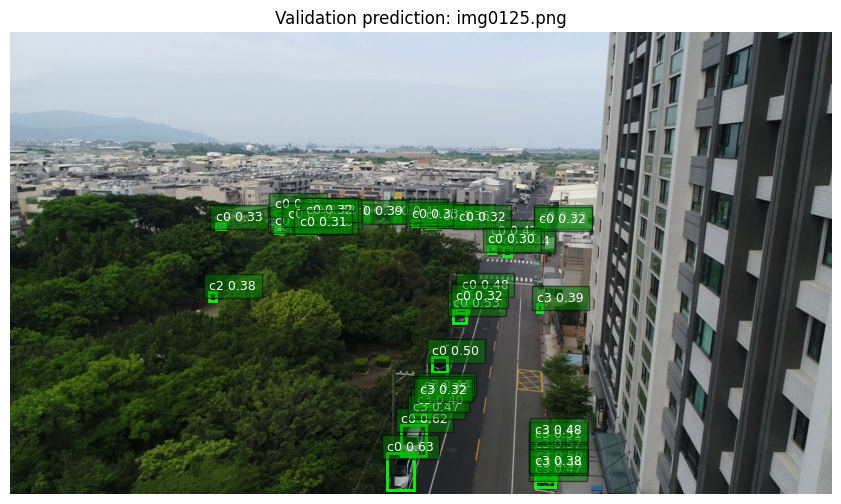

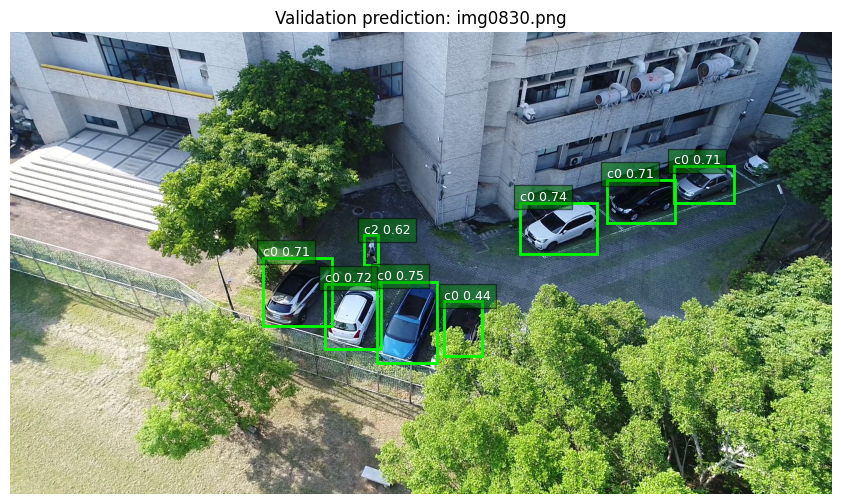

In [22]:
best_weights_path = "/home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/runs/yolov12m_1280_hybrid_resample6/weights/best.pt"
best_model = YOLO(best_weights_path)

def visualize_samples(model: YOLO, image_paths: List[Path], score_thresh: float = 0.3, max_images: int = 3):
    chosen = random.sample(image_paths, k=min(max_images, len(image_paths)))
    for path in chosen:
        results = model.predict(
            source=str(path),
            imgsz=cfg.image_size,
            conf=score_thresh,
            iou=cfg.iou_threshold,
            max_det=300,
            verbose=False,
        )[0]
        boxes = results.boxes
        img = Image.open(path).convert("RGB")
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.imshow(img)
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                xyxy = box.xyxy.cpu().numpy()[0]
                conf = float(box.conf.cpu().item())
                cls = int(box.cls.cpu().item())
                xmin, ymin, xmax, ymax = xyxy
                rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color="lime", linewidth=2)
                ax.add_patch(rect)
                ax.text(
                    xmin,
                    max(0, ymin - 5),
                    f"c{cls} {conf:.2f}",
                    color="white",
                    fontsize=9,
                    bbox=dict(facecolor="green", alpha=0.5),
                )
        ax.set_title(f"Validation prediction: {path.name}")
        ax.axis("off")
        plt.show()

val_image_paths = sorted(cfg.yolo_images_val.glob("*.png"))
if val_image_paths:
    visualize_samples(best_model, val_image_paths, score_thresh=0.3, max_images=2)
else:
    print("No validation images found.")

## 8. Submission Generation

Run inference on the 550 test images and format predictions like `sample_submission.csv`. When no boxes survive the confidence threshold we emit a tiny dummy detection to keep Kaggle happy.

In [23]:
def format_prediction_string(result, score_thresh: float, boxes_override: Optional[np.ndarray] = None) -> str:
    if boxes_override is not None:
        boxes_array = np.asarray(boxes_override, dtype=np.float32)
        if boxes_array.size == 0:
            return f"{cfg.dummy_conf:.6f} 0.00 0.00 1.00 1.00 {cfg.dummy_label}"

        parts: List[str] = []
        for xmin, ymin, xmax, ymax, conf, cls in boxes_array:
            conf = float(conf)
            if conf < score_thresh:
                continue
            xmin = float(xmin)
            ymin = float(ymin)
            xmax = float(xmax)
            ymax = float(ymax)
            width = max(1.0, xmax - xmin)
            height = max(1.0, ymax - ymin)
            parts.append(f"{conf:.6f} {xmin:.2f} {ymin:.2f} {width:.2f} {height:.2f} {int(cls)}")

        if not parts:
            parts.append(f"{cfg.dummy_conf:.6f} 0.00 0.00 1.00 1.00 {cfg.dummy_label}")
        return " ".join(parts)

    boxes = getattr(result, "boxes", None)
    if boxes is None or len(boxes) == 0:
        return f"{cfg.dummy_conf:.6f} 0.00 0.00 1.00 1.00 {cfg.dummy_label}"

    parts: List[str] = []
    for box in boxes:
        conf = float(box.conf.cpu().item())
        if conf < score_thresh:
            continue
        cls = int(box.cls.cpu().item())
        xmin, ymin, xmax, ymax = box.xyxy.cpu().numpy()[0]
        width = max(1.0, xmax - xmin)
        height = max(1.0, ymax - ymin)
        parts.append(f"{conf:.6f} {xmin:.2f} {ymin:.2f} {width:.2f} {height:.2f} {cls}")

    if not parts:
        parts.append(f"{cfg.dummy_conf:.6f} 0.00 0.00 1.00 1.00 {cfg.dummy_label}")
    return " ".join(parts)


def run_inference_to_submission(
    model: YOLO,
    cfg: TrainConfig,
    *,
    score_thresh: Optional[float] = None,
    iou_thresh: Optional[float] = None,
    predict_conf: Optional[float] = None,
    output_path: Optional[Path] = None,
) -> Path:
    test_paths = sorted(cfg.yolo_images_test.glob("*.png"))
    if not test_paths:
        raise RuntimeError(f"No test images found under {cfg.yolo_images_test}")

    score_thresh = float(score_thresh if score_thresh is not None else cfg.score_threshold)
    iou_thresh = float(iou_thresh if iou_thresh is not None else cfg.iou_threshold)
    predict_conf = float(predict_conf if predict_conf is not None else max(1e-4, min(0.05, score_thresh * 0.5)))

    prediction_rows: List[Dict[str, Any]] = []
    for path in tqdm(test_paths, desc="Test inference"):
        image_id = int(path.stem.replace("img", ""))
        result = model.predict(
            source=str(path),
            imgsz=cfg.image_size,
            conf=predict_conf,
            iou=iou_thresh,
            max_det=300,
            verbose=False,
        )[0]
        pred_string = format_prediction_string(result, score_thresh)
        prediction_rows.append({
            "Image_ID": image_id,
            "PredictionString": pred_string,
        })

    submission_df = pd.DataFrame(prediction_rows)
    submission_df.sort_values("Image_ID", inplace=True)

    output_path = Path(output_path) if output_path else cfg.project_root / "submission.csv"
    submission_df.to_csv(output_path, index=False)
    print(f"Submission saved to {output_path}")
    return output_path


if cfg.use_kfold:
    if not kfold_weight_paths:
        raise RuntimeError("未找到 k-fold 權重，請先完成 run_kfold_training。")
    ensemble_name = cfg.kfold_output_name or f"{cfg.run_name}_kfold_ensemble"
    submission_path = run_ensemble_inference_to_submission(
        kfold_weight_paths,
        cfg,
        fuse_iou=cfg.kfold_fuse_iou,
        score_thresh=cfg.score_threshold,
        predict_conf=None,
        output_name=ensemble_name,
    )
else:
    submission_path = run_inference_to_submission(best_model, cfg)
submission_path


Test inference: 100%|██████████| 550/550 [00:42<00:00, 13.08it/s]

Submission saved to /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/submission.csv


PosixPath('/home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/submission.csv')

In [25]:
# ============================================================
# CSV Fusion - 融合多個 submission.csv（後處理式 Ensemble）
# ============================================================

def parse_prediction_string(pred_string: str) -> np.ndarray:
    """
    解析 PredictionString 為 boxes 陣列
    
    格式：'conf x y w h cls conf x y w h cls ...'
    輸出：[N, 6] 陣列，每列為 [xmin, ymin, xmax, ymax, conf, cls]
    """
    if not pred_string or pred_string.strip() == "" or pred_string.strip() == "nan":
        return np.zeros((0, 6), dtype=np.float32)
    
    parts = pred_string.split()
    if len(parts) % 6 != 0:
        print(f"Warning: Invalid prediction string format (length={len(parts)}): {pred_string[:100]}...")
        return np.zeros((0, 6), dtype=np.float32)
    
    boxes = []
    for i in range(0, len(parts), 6):
        try:
            conf = float(parts[i])
            x = float(parts[i + 1])
            y = float(parts[i + 2])
            w = float(parts[i + 3])
            h = float(parts[i + 4])
            cls = int(parts[i + 5])
            
            # 轉換 xywh → xyxy
            xmin = x
            ymin = y
            xmax = x + w
            ymax = y + h
            
            boxes.append([xmin, ymin, xmax, ymax, conf, cls])
        except (ValueError, IndexError) as e:
            print(f"Warning: Failed to parse box at index {i}: {e}")
            continue
    
    return np.asarray(boxes, dtype=np.float32) if boxes else np.zeros((0, 6), dtype=np.float32)


def encode_boxes_to_string(boxes: np.ndarray, score_thresh: float = 0.0) -> str:
    """
    將 boxes 陣列編碼為 PredictionString
    
    輸入：[N, 6] 陣列 [xmin, ymin, xmax, ymax, conf, cls]
    輸出：'conf x y w h cls conf x y w h cls ...'
    """
    if boxes.size == 0:
        # 返回 dummy 預測（必須有至少一個預測）
        return "0.001 0.00 0.00 1.00 1.00 0"
    
    parts = []
    for box in boxes:
        xmin, ymin, xmax, ymax, conf, cls = box
        if conf < score_thresh:
            continue
        
        # 轉換 xyxy → xywh
        x = float(xmin)
        y = float(ymin)
        w = max(1.0, float(xmax - xmin))
        h = max(1.0, float(ymax - ymin))
        
        parts.append(f"{conf:.6f} {x:.2f} {y:.2f} {w:.2f} {h:.2f} {int(cls)}")
    
    if not parts:
        return "0.001 0.00 0.00 1.00 1.00 0"
    
    return " ".join(parts)


def fuse_detections_from_arrays(
    boxes_list: List[np.ndarray],
    iou_thresh: float = 0.55,
) -> np.ndarray:
    """
    融合多個 boxes 陣列（CSV 版本的 fuse_detections）
    
    Args:
        boxes_list: 多個 [N, 6] 陣列的列表
        iou_thresh: IoU 閾值
    
    Returns:
        融合後的 [M, 6] 陣列
    """
    # 過濾空陣列
    non_empty = [arr for arr in boxes_list if arr.size > 0]
    if not non_empty:
        return np.zeros((0, 6), dtype=np.float32)
    
    # 合併所有框
    concatenated = np.concatenate(non_empty, axis=0)
    
    # 按類別分組處理
    fused_outputs = []
    for cls_value in np.unique(concatenated[:, 5].astype(int)):
        class_mask = concatenated[:, 5] == cls_value
        class_boxes = concatenated[class_mask, :4]  # xyxy
        class_scores = concatenated[class_mask, 4]  # conf
        
        # 融合同類別的框
        fused_class = fuse_class_boxes(class_boxes, class_scores, iou_thresh)
        
        for coords, score in fused_class:
            fused_outputs.append([
                coords[0],  # xmin
                coords[1],  # ymin
                coords[2],  # xmax
                coords[3],  # ymax
                score,      # conf
                float(cls_value),  # cls
            ])
    
    if not fused_outputs:
        return np.zeros((0, 6), dtype=np.float32)
    
    return np.asarray(fused_outputs, dtype=np.float32)


def merge_submission_csvs(
    csv_paths: List[Path],
    cfg: TrainConfig,
    *,
    fuse_iou: float = 0.55,
    score_thresh: float = 0.01,
    output_path: Optional[Path] = None,
) -> Path:
    """
    融合多個 submission.csv（後處理式 Ensemble）
    
    Args:
        csv_paths: 多個 submission.csv 的路徑
        cfg: TrainConfig
        fuse_iou: 融合框的 IoU 閾值
        score_thresh: 最終輸出的信心閾值
        output_path: 輸出路徑
    
    Returns:
        融合後的 submission.csv 路徑
    """
    # ❶ 讀取所有 CSV
    print("=" * 70)
    print(f"📊 Merging {len(csv_paths)} submission CSVs...")
    print("=" * 70)
    
    dfs = []
    for i, path in enumerate(csv_paths, 1):
        if not path.exists():
            raise FileNotFoundError(f"CSV file not found: {path}")
        df = pd.read_csv(path)
        dfs.append(df)
        print(f"  [{i}/{len(csv_paths)}] Loaded: {path.name} ({len(df)} images)")
    
    # ❷ 確保所有 CSV 的 Image_ID 一致
    image_ids = dfs[0]["Image_ID"].values
    for i, df in enumerate(dfs[1:], start=1):
        if not (df["Image_ID"].values == image_ids).all():
            raise ValueError(f"CSV {i} 的 Image_ID 與第一個 CSV 不一致！")
    
    print(f"\n  → Total images: {len(image_ids)}")
    print(f"  → Fusion IoU threshold: {fuse_iou}")
    print(f"  → Score threshold: {score_thresh}")
    print("=" * 70)
    
    # ❸ 對每張圖片融合預測
    merged_rows = []
    for img_id in tqdm(image_ids, desc="🔄 Fusing predictions"):
        # 取得該圖片在所有 CSV 中的預測字串
        pred_strings = [
            df.loc[df["Image_ID"] == img_id, "PredictionString"].values[0]
            for df in dfs
        ]
        
        # 解析字串為 boxes
        all_boxes = [parse_prediction_string(str(pred_str)) for pred_str in pred_strings]
        
        # 融合 boxes
        fused_boxes = fuse_detections_from_arrays(all_boxes, iou_thresh=fuse_iou)
        
        # 重新編碼為字串
        pred_string = encode_boxes_to_string(fused_boxes, score_thresh=score_thresh)
        
        merged_rows.append({
            "Image_ID": img_id,
            "PredictionString": pred_string,
        })
    
    # ❹ 儲存融合後的 CSV
    merged_df = pd.DataFrame(merged_rows)
    merged_df.sort_values("Image_ID", inplace=True)
    
    if output_path is None:
        timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        output_path = cfg.project_root / f"submission_fused_{timestamp}.csv"
    
    merged_df.to_csv(output_path, index=False)
    
    print("=" * 70)
    print(f"✅ Fused submission saved to:")
    print(f"   {output_path}")
    print("=" * 70)
    
    # 統計資訊
    total_boxes = sum(len(parse_prediction_string(str(s))) for s in merged_df["PredictionString"])
    avg_boxes = total_boxes / len(merged_df)
    print(f"\n📈 Statistics:")
    print(f"  → Total predictions: {total_boxes:,}")
    print(f"  → Average boxes per image: {avg_boxes:.2f}")
    print("=" * 70)
    
    return output_path





In [29]:
# ============================================================
# 執行：融合 submission_file 資料夾中的所有 submission.csv
# ============================================================

# ❶ 設定 submission_file 資料夾路徑
submission_folder = Path("/home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/submission_file")

# ❷ 自動搜尋所有 .csv 檔案
csv_files = sorted(submission_folder.glob("*.csv"))

print("=" * 70)
print(f"📁 Found {len(csv_files)} CSV files in {submission_folder.name}:")
print("=" * 70)
for i, csv_path in enumerate(csv_files, 1):
    file_size = csv_path.stat().st_size / 1024  # KB
    print(f"  [{i}] {csv_path.name:<40s} ({file_size:.1f} KB)")
print("=" * 70)

# ❸ 檢查是否有檔案
if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {submission_folder}")

if len(csv_files) == 1:
    print("⚠️  Warning: Only 1 CSV file found. Fusion requires at least 2 files.")
    print("   Skipping fusion...")
else:
    # ❹ 執行融合
    print(f"\n🚀 Starting fusion of {len(csv_files)} CSV files...")
    
    # 設定融合參數
    FUSE_IOU = 0.85         # IoU 閾值（控制框融合的嚴格程度）
    SCORE_THRESH = 0.001     # 最終輸出的信心閾值
    
    # 自動生成輸出檔名（包含融合檔案數量）
    output_filename = f"submission_fused_{len(csv_files)}models.csv"
    output_path = cfg.project_root / output_filename
    
    # 執行融合
    merged_csv = merge_submission_csvs(
        csv_files,
        cfg,
        fuse_iou=FUSE_IOU,
        score_thresh=SCORE_THRESH,
        output_path=output_path,
    )
    
    print("\n" + "=" * 70)
    print("✅ CSV Fusion Completed Successfully!")
    print("=" * 70)
    print(f"\n📊 Summary:")
    print(f"  → Input files: {len(csv_files)}")
    print(f"  → Fusion IoU: {FUSE_IOU}")
    print(f"  → Score threshold: {SCORE_THRESH}")
    print(f"  → Output: {merged_csv.name}")
    print("\n" + "=" * 70)
    
    # ❺ 快速驗證：比較融合前後的預測數量
    print("\n📈 Validation:")
    
    # 讀取融合後的 CSV
    merged_df = pd.read_csv(merged_csv)
    
    # 計算融合後的總預測框數量
    merged_total = sum(len(parse_prediction_string(str(s))) for s in merged_df["PredictionString"])
    
    # 計算所有輸入 CSV 的平均預測框數量
    input_totals = []
    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        total = sum(len(parse_prediction_string(str(s))) for s in df["PredictionString"])
        input_totals.append(total)
    
    avg_input = np.mean(input_totals)
    
    print(f"  → Average predictions per input CSV: {avg_input:.0f}")
    print(f"  → Fused predictions: {merged_total}")
    print(f"  → Ratio (fused/avg): {merged_total/avg_input:.2f}x")
    
    if merged_total < avg_input * 0.5:
        print("  ⚠️  Warning: Fused predictions are much lower than average.")
        print("     Consider lowering fuse_iou or score_thresh.")
    elif merged_total > avg_input * 1.5:
        print("  ⚠️  Warning: Fused predictions are much higher than average.")
        print("     Consider raising fuse_iou.")
    else:
        print("  ✅ Fusion ratio looks reasonable!")
    
    print("=" * 70)


📁 Found 7 CSV files in submission_file:
  [1] submission (1).csv                       (2535.2 KB)
  [2] submission (2).csv                       (2968.1 KB)
  [3] submission (3).csv                       (3763.4 KB)
  [4] submission (4).csv                       (4439.1 KB)
  [5] submission.csv                           (2690.7 KB)
  [6] submission_yolov12m_2880 (1).csv         (2393.8 KB)
  [7] submission_yolov12m_2880 (2).csv         (2922.9 KB)

🚀 Starting fusion of 7 CSV files...
📊 Merging 7 submission CSVs...
  [1/7] Loaded: submission (1).csv (550 images)
  [2/7] Loaded: submission (2).csv (550 images)
  [3/7] Loaded: submission (3).csv (550 images)
  [4/7] Loaded: submission (4).csv (550 images)
  [5/7] Loaded: submission.csv (550 images)
  [6/7] Loaded: submission_yolov12m_2880 (1).csv (550 images)
  [7/7] Loaded: submission_yolov12m_2880 (2).csv (550 images)

  → Total images: 550
  → Fusion IoU threshold: 0.85
  → Score threshold: 0.001


🔄 Fusing predictions: 100%|██████████| 550/550 [04:53<00:00,  1.88it/s]



✅ Fused submission saved to:
   /home/tony/Downloads/NTU_CVPDL/H2/CVPDL_hw2/CVPDL_hw2/submission_fused_7models.csv

📈 Statistics:
  → Total predictions: 381,373
  → Average boxes per image: 693.41

✅ CSV Fusion Completed Successfully!

📊 Summary:
  → Input files: 7
  → Fusion IoU: 0.85
  → Score threshold: 0.001
  → Output: submission_fused_7models.csv


📈 Validation:

✅ CSV Fusion Completed Successfully!

📊 Summary:
  → Input files: 7
  → Fusion IoU: 0.85
  → Score threshold: 0.001
  → Output: submission_fused_7models.csv


📈 Validation:
  → Average predictions per input CSV: 85705
  → Fused predictions: 381373
  → Ratio (fused/avg): 4.45x
  ⚠️  Warning: Fused predictions are much higher than average.
     Consider raising fuse_iou.
  → Average predictions per input CSV: 85705
  → Fused predictions: 381373
  → Ratio (fused/avg): 4.45x
  ⚠️  Warning: Fused predictions are much higher than average.
     Consider raising fuse_iou.
